# Operational Analyst DustinxDelixia EDA

In [1]:
%pip install -q -r /home/jovyan/jupyter_requirements.txt
%pip install -q clickhouse-connect seaborn matplotlib

import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, datediff, when, count, avg, isnull, hour, expr
import clickhouse_connect

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (12, 6), 'axes.titlesize': 16})

spark = SparkSession.builder \
    .appName("DustiniaDelixia_Master_EDA") \
    .config("spark.driver.memory", "1g") \
    .getOrCreate()

data_path = "/home/jovyan/raw_data"
print("PySpark initialized and ready for processing.")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
PySpark initialized and ready for processing.


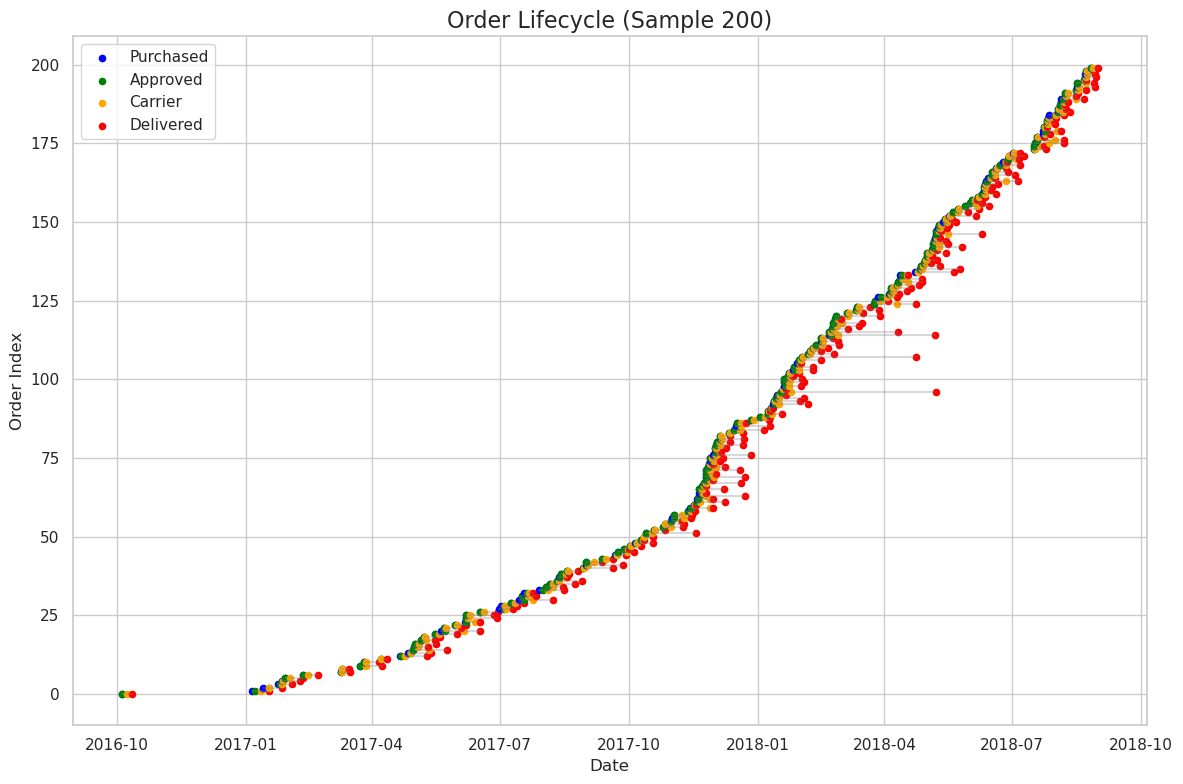

In [2]:
orders_raw = spark.read.csv(f"{data_path}/orders.csv", header=True, inferSchema=True)

delivered_sample = orders_raw.filter(col("order_status") == "delivered") \
    .dropna() \
    .sample(fraction=0.1, seed=42) \
    .limit(200) \
    .toPandas()

time_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date']
for time_col in time_cols:
    delivered_sample[time_col] = pd.to_datetime(delivered_sample[time_col])

delivered_sample = delivered_sample.sort_values('order_purchase_timestamp').reset_index(drop=True)

plt.figure(figsize=(12, 8))
for i, row in delivered_sample.iterrows():
    plt.plot([row['order_purchase_timestamp'], row['order_delivered_customer_date']], [i, i], color='grey', alpha=0.3)
    plt.scatter(row['order_purchase_timestamp'], i, color='blue', s=20, label='Purchased' if i==0 else "")
    plt.scatter(row['order_approved_at'], i, color='green', s=20, label='Approved' if i==0 else "")
    plt.scatter(row['order_delivered_carrier_date'], i, color='orange', s=20, label='Carrier' if i==0 else "")
    plt.scatter(row['order_delivered_customer_date'], i, color='red', s=20, label='Delivered' if i==0 else "")

plt.title("Order Lifecycle (Sample 200)")
plt.xlabel("Date")
plt.ylabel("Order Index")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


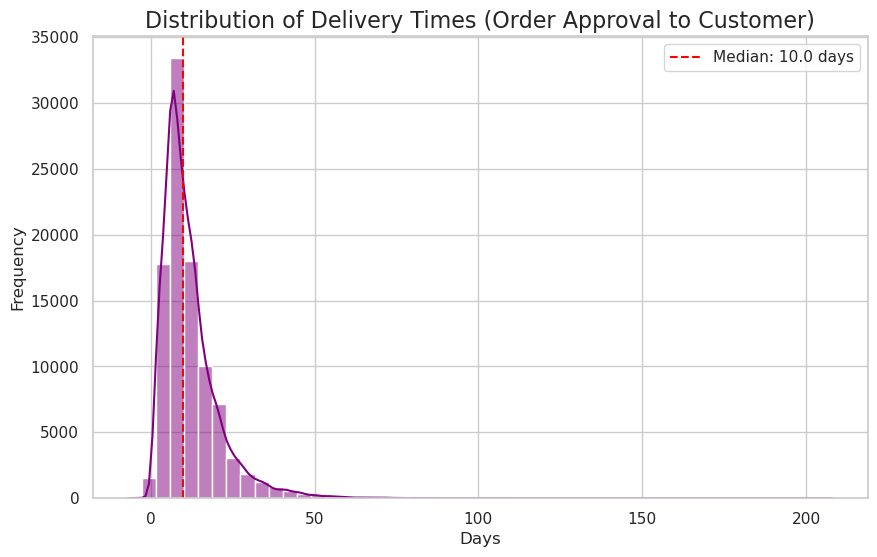

In [3]:
delivered_orders = orders_raw.filter(col("order_status") == "delivered") \
    .dropna() \
    .withColumn("delivery_duration_days",
                datediff(col("order_delivered_customer_date"), col("order_approved_at")))

delivery_hist = delivered_orders.select("delivery_duration_days").toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(delivery_hist['delivery_duration_days'], bins=50, kde=True, color='purple')
plt.axvline(delivery_hist['delivery_duration_days'].median(), color='red', linestyle='dashed', label=f"Median: {delivery_hist['delivery_duration_days'].median():.1f} days")
plt.title("Distribution of Delivery Times (Order Approval to Customer)")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.legend()
plt.show()


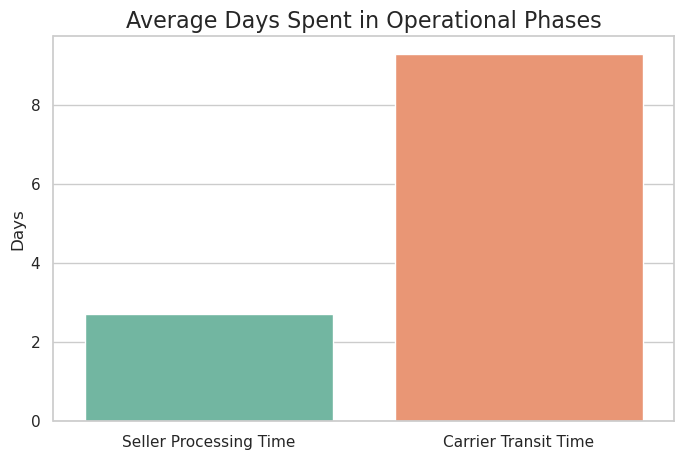

In [4]:
delivered_orders = delivered_orders.withColumn("seller_processing_days", datediff(col("order_delivered_carrier_date"), col("order_approved_at")))
delivered_orders = delivered_orders.withColumn("carrier_transit_days", datediff(col("order_delivered_customer_date"), col("order_delivered_carrier_date")))

components_pd = delivered_orders.select("seller_processing_days", "carrier_transit_days").summary("mean").toPandas()
mean_processing = float(components_pd.loc[0, 'seller_processing_days'])
mean_transit = float(components_pd.loc[0, 'carrier_transit_days'])

plt.figure(figsize=(8, 5))
sns.barplot(x=['Seller Processing Time', 'Carrier Transit Time'], y=[mean_processing, mean_transit], palette="Set2")
plt.title("Average Days Spent in Operational Phases")
plt.ylabel("Days")
plt.show()

In [5]:
import os

client = clickhouse_connect.get_client(
    host='clickhouse', 
    port=8123, 
    username='jupyter_reader', 
    password='jupyter_readonly_pass',
    database='operational_db'
)

print("Successfully connected to the ClickHouse Data Warehouse!")

Successfully connected to the ClickHouse Data Warehouse!


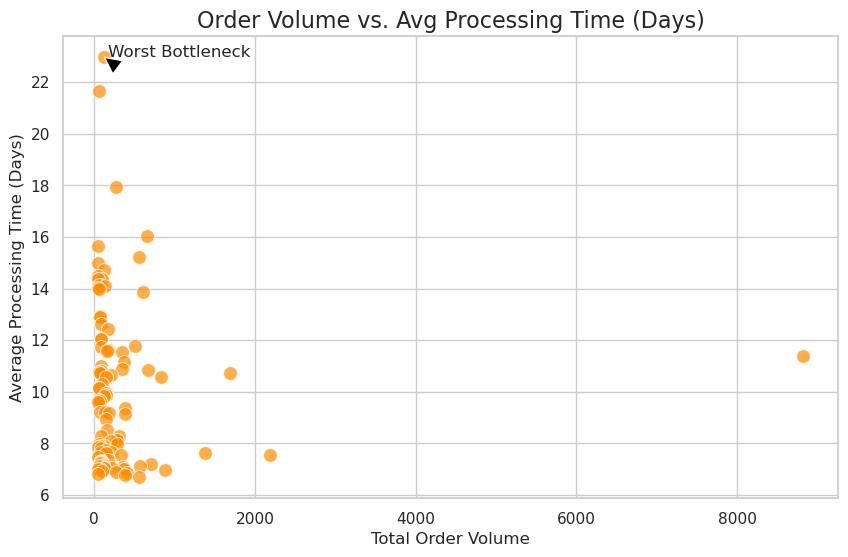

In [7]:
query_sellers = """
    SELECT 
        s.seller_id,
        COUNT(f.order_id) as order_volume,
        AVG(f.seller_processing_days) as avg_processing_time
    FROM fact_deliveries f
    JOIN dim_sellers s ON f.seller_id = s.seller_id
    WHERE f.seller_processing_days IS NOT NULL AND f.seller_processing_days > 0
    GROUP BY s.seller_id
    HAVING order_volume > 50
    ORDER BY avg_processing_time DESC
    LIMIT 100
"""
df_sellers = client.query_df(query_sellers)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='order_volume', y='avg_processing_time', data=df_sellers, color='darkorange', alpha=0.7, s=100)
plt.title("Order Volume vs. Avg Processing Time (Days)")
plt.xlabel("Total Order Volume")
plt.ylabel("Average Processing Time (Days)")

worst_seller = df_sellers.iloc[0]
plt.annotate('Worst Bottleneck', 
             xy=(worst_seller['order_volume'], worst_seller['avg_processing_time']),\
             xytext=(worst_seller['order_volume'] + 50, worst_seller['avg_processing_time']),\
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

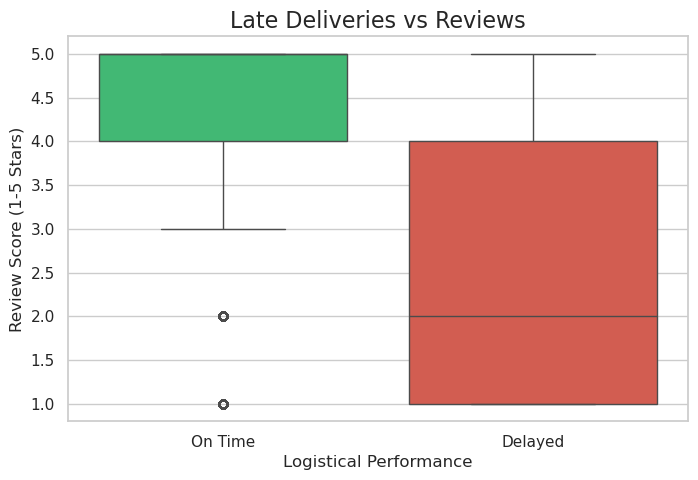

In [8]:
query_reviews = """
    SELECT 
        f.is_delayed,
        r.review_score
    FROM fact_deliveries f
    JOIN dim_reviews r ON f.order_id = r.order_id
    WHERE f.is_delayed IS NOT NULL AND r.review_score IS NOT NULL
"""
df_reviews = client.query_df(query_reviews)
df_reviews['Delivery Status'] = df_reviews['is_delayed'].map({0: 'On Time', 1: 'Delayed'})

plt.figure(figsize=(8, 5))
sns.boxplot(x='Delivery Status', y='review_score', data=df_reviews, palette={'Delayed': '#e74c3c', 'On Time': '#2ecc71'})
plt.title("Late Deliveries vs Reviews")
plt.xlabel("Logistical Performance")
plt.ylabel("Review Score (1-5 Stars)")
plt.show()
